# Assignment 2 - Problem 1

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
df_org = pd.read_csv("data/data-a2-p1.csv")

In [3]:
df_org

,student_id,attendance_percent,study_hours_per_week,motivation_level,stress_level,online_activity_hours,assignment_score
0,S01,79,12,6.8,3.1,5.5,81
1,S02,88,16,5.3,5.6,6.4,83
2,S03,74,12,4.7,3.0,4.8,78
3,S04,94,15,8.4,5.5,4.1,87
4,S05,78,15,7.5,8.0,5.0,79
...,...,...,...,...,...,...,...
75,S76,94,26,7.9,3.3,5.1,92
76,S77,77,10,4.4,3.3,5.3,77
77,S78,91,17,4.7,3.4,5.3,86
78,S79,73,18,5.7,5.9,2.6,79


In [4]:
print("dropping the student IDs")
import plotly.express as px
df = df_org.drop(df_org.columns[0], axis=1)

df

dropping the student IDs


,attendance_percent,study_hours_per_week,motivation_level,stress_level,online_activity_hours,assignment_score
0,79,12,6.8,3.1,5.5,81
1,88,16,5.3,5.6,6.4,83
2,74,12,4.7,3.0,4.8,78
3,94,15,8.4,5.5,4.1,87
4,78,15,7.5,8.0,5.0,79
...,...,...,...,...,...,...
75,94,26,7.9,3.3,5.1,92
76,77,10,4.4,3.3,5.3,77
77,91,17,4.7,3.4,5.3,86
78,73,18,5.7,5.9,2.6,79


In [5]:
fig = px.scatter_matrix(df, dimensions = ['attendance_percent','study_hours_per_week','assignment_score','stress_level','online_activity_hours', 'motivation_level'])
fig.update_layout(font=dict(size=9))
fig.update_layout(width = 900, height = 900)
fig.show()

In [6]:
### A2-P1 a) Construct and visualize a histogram of each features.
### A2-P1 b) dd three vertical lines on the histograms for mean, median, and mode of the distributions.
# Include proper legend for the figures.

def compute_mean_median_mode(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    mean = float(s.mean())
    median = float(s.median())
    modes = s.mode()
    mode = float(modes.iloc[0]) if len(modes) else float("nan")
    return mean, median, mode

def plot_histogram_with_the_vline_stats(df, n_bins=20):
    print("histogram when number of bins is", n_bins)
    print("solid is mean")
    print("dash is median")
    print("dot is mode")
    
    feature_list = [c for c in df.columns]
    for feature in feature_list:
    
        mean, median, mode = compute_mean_median_mode(df[feature])
        
        fig = px.histogram(df, x=feature, nbins=n_bins, title=f"Histogram of {feature}", opacity=0.85,)
    
        # add vlines for mean, median, mode
        fig.add_vline(x=mean, line_width=3, line_dash="solid")
        fig.add_vline(x=median, line_width=3, line_dash="dash")
        fig.add_vline(x=mode, line_width=3, line_dash="dot")
        fig.show()

In [7]:
plot_histogram_with_the_vline_stats(df, n_bins=10)

histogram when number of bins is 10
solid is mean
dash is median
dot is mode


In [8]:
plot_histogram_with_the_vline_stats(df, n_bins=20)

histogram when number of bins is 20
solid is mean
dash is median
dot is mode


In [9]:
plot_histogram_with_the_vline_stats(df, n_bins=30)

histogram when number of bins is 30
solid is mean
dash is median
dot is mode


In [10]:
### A2-P1 c) Report/discuss which distributions each feature resemble.
# This is open question to see if questions can analyze the histogram and reason.

In [11]:
### A2-P1 d) Visualize the following figures: y-axis to be assignment score, and x-axis to be rest of the features.
# Plot each in a separate figure.

feature_list = [c for c in df.columns]

for feature in feature_list:
    if feature == "assignment_score":
        continue

    fig = px.density_heatmap(df, x = feature, y = 'assignment_score')
    fig.show()

In [12]:
### A2-P1 e) Calculate the correlation between assignment score and all other features.

correlation = df["assignment_score"].corr(df["attendance_percent"])
print("Correlation between assignment_score and attendance_percent = " ,str(correlation))

correlation = df["assignment_score"].corr(df["study_hours_per_week"])
print("Correlation between assignment_score and study_hours_per_week = " ,str(correlation))

correlation = df["assignment_score"].corr(df["motivation_level"])
print("Correlation between assignment_score and motivation_level = " ,str(correlation))

correlation = df["assignment_score"].corr(df["stress_level"])
print("Correlation between assignment_score and stress_level = " ,str(correlation))

correlation = df["assignment_score"].corr(df["online_activity_hours"])
print("Correlation between assignment_score and online_activity_hours = " ,str(correlation))

Correlation between assignment_score and attendance_percent =  0.8240683651651446
Correlation between assignment_score and study_hours_per_week =  0.7799944245961806
Correlation between assignment_score and motivation_level =  0.5459477732757195
Correlation between assignment_score and stress_level =  -0.3343108390182896
Correlation between assignment_score and online_activity_hours =  -0.1846411426408057


In [13]:
### A2-P1 f) Discuss the relationships and comment on the obtained results.
# the relation can be discussed given the above numbers.
# When positive the features are positively correaltion, and
# when negative, the increase of feature won't be helpful in getting a higher assignment score.
# For example, having large number of online_activity_hours has negative impact on the assignment score.
# You can also discuss these based on d) as the relation between features is not linear.
# For example, one feature can start to become correlated with assignment score when they get extreme in values.

                       attendance_percent  study_hours_per_week  \
attendance_percent               1.000000              0.547733   
study_hours_per_week             0.547733              1.000000   
motivation_level                 0.481868              0.358593   
stress_level                    -0.194754             -0.130968   
online_activity_hours           -0.003005             -0.065729   
assignment_score                 0.824068              0.779994   

                       motivation_level  stress_level  online_activity_hours  \
attendance_percent             0.481868     -0.194754              -0.003005   
study_hours_per_week           0.358593     -0.130968              -0.065729   
motivation_level               1.000000     -0.067065               0.053015   
stress_level                  -0.067065      1.000000               0.087517   
online_activity_hours          0.053015      0.087517               1.000000   
assignment_score               0.545948     -0.334

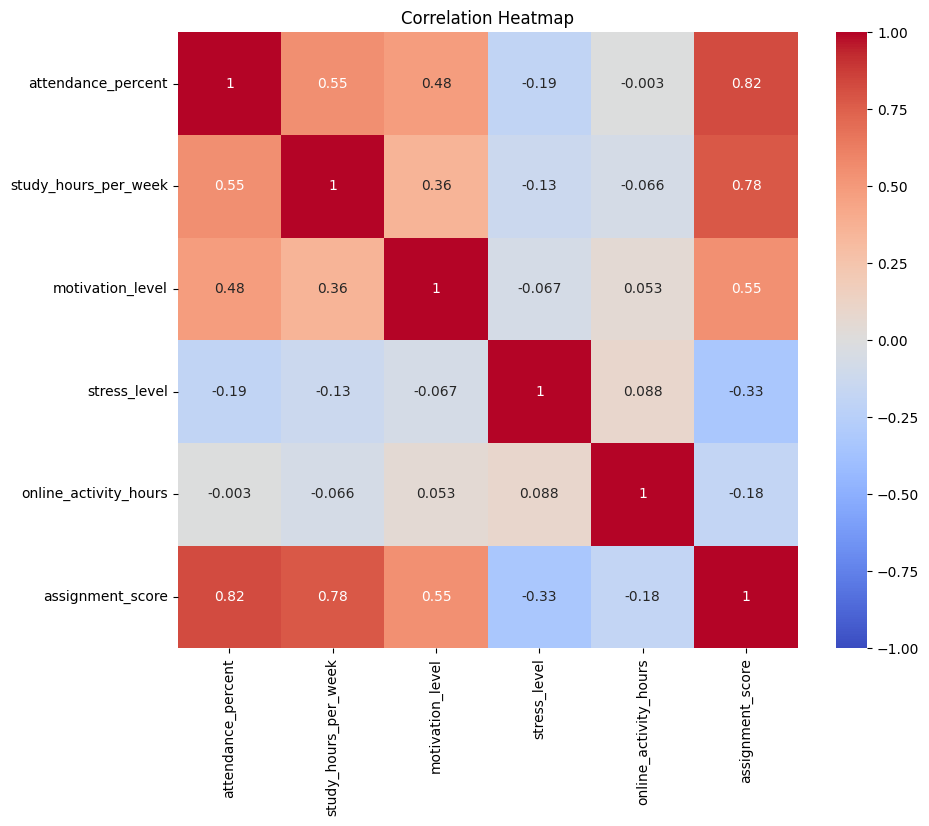

In [14]:
### alternatively, you can use seaborn to compute and visualize correlation matrix.

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
print(correlation_matrix)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.show()

Correlation is a commonly used statistical measure to examine the relationship between two continuous features. However, it is not a perfect metric, as it is sensitive only to linear associations between features. Non-linear relationships, which are common in many real-world datasets, may not be adequately captured by correlation. Additionally, anomalies in the dataset can influence the correlation calculation.

An examination of the correlations reveals several relationships between the features under study. Notably, two pairs assignment_score (higher values mean better grade) and attendance_percent, or study_hours_per_week, or motivation_level exhibit a strong positive correlation (corr of 0.82, 0.77, 0.54, respectively). This suggests that students with higher attendance_percent and study_hours_per_week tend to have better assignment_score. Motivation also corelates and seems to be helpful. Furthermore, stress_level and online_activity_hours has negative correlation with assignment_score. Hence, the increase in the two feature does not seem to be helpful in the increase of assignment_score.

Overall, these findings provide valuable insight into the relationships among the features, but __caution__ should be exercised in interpreting the results, given the limitations (and sign) of correlation as a measure of association.

We provided interpretation of correlations above for assignment_score. You can read variety of other correlation between features. For example, pairs of study_hours_per_week and motivation_level and attendance_percent are positively correlated.

# Assignment 2 - Problem 2

In [15]:
df_p2 = pd.read_csv("data/data-a2-p2.csv")
print(df_p2)

   student_id  passing_course  model_1_score  model_2_score
0        T001               1          0.848          1.000
1        T002               1          0.656          0.713
2        T003               1          0.823          1.000
3        T004               1          0.403          0.847
4        T005               1          0.523          0.636
..        ...             ...            ...            ...
95       T096               1          0.684          1.000
96       T097               1          0.491          0.662
97       T098               1          0.773          0.886
98       T099               1          0.681          0.906
99       T100               1          0.678          0.980

[100 rows x 4 columns]


In [16]:
### A2-P2 a) Using a classification threshold of 0.50 on the prediction score, construct the confusion matrix for each of the models.
# Use this threshold for b) and c) below.

threshold = 0.50

# get the prediction results
df_p2['prediction_1'] = df_p2['model_1_score'].apply(lambda x: True if x >= threshold else False)
df_p2['prediction_2'] = df_p2['model_2_score'].apply(lambda x: True if x >= threshold else False)
print(df_p2)
print(type(df_p2['passing_course']))

   student_id  passing_course  model_1_score  model_2_score  prediction_1  \
0        T001               1          0.848          1.000          True   
1        T002               1          0.656          0.713          True   
2        T003               1          0.823          1.000          True   
3        T004               1          0.403          0.847         False   
4        T005               1          0.523          0.636          True   
..        ...             ...            ...            ...           ...   
95       T096               1          0.684          1.000          True   
96       T097               1          0.491          0.662         False   
97       T098               1          0.773          0.886          True   
98       T099               1          0.681          0.906          True   
99       T100               1          0.678          0.980          True   

    prediction_2  
0           True  
1           True  
2           True  

In [17]:
# You can see that 80 percent of the students have passed.
print(sum(df_p2['passing_course']), "have passing_course of label 1 out of", len(df_p2['passing_course']))

80 have passing_course of label 1 out of 100


In [18]:
# We are interested in failing students, so I create a new label being 1 if failing, and 0 if passing.
# So that we can use that as the positive target in our analysis.
# So 20 percent are failing
df_p2["failing_course"] = df_p2["passing_course"].map({1: 0, 0: 1})
print(sum(df_p2['failing_course']), "have failing_course of label 1 out of", len(df_p2['failing_course']))

# get the prediction results
df_p2['prediction_failing_1'] = df_p2['model_1_score'].apply(lambda x: True if x < threshold else False)
df_p2['prediction_failing_2'] = df_p2['model_2_score'].apply(lambda x: True if x < threshold else False)

20 have failing_course of label 1 out of 100


In [19]:
### A1-P2 a) create a function to compute confusion matrix
def confusion_matrix(y_predict, y_actual):

    true_positives = y_predict & y_actual
    true_negatives = (y_predict==False) & (y_actual==False)
    false_positives = y_predict & (y_actual==False)
    false_negatives = (y_predict == False) & y_actual

    num_true_positives = true_positives.sum()
    num_true_negatives = true_negatives.sum()
    num_false_positives = false_positives.sum()
    num_false_negatives = false_negatives.sum()

    confusion_matrix = np.array([
        [num_true_positives,num_false_negatives],
        [num_false_positives, num_true_negatives]
    ])
    return confusion_matrix

In [20]:
confusion_matrix_1 = confusion_matrix(df_p2['prediction_failing_1'], df_p2['failing_course'])
confusion_matrix_2 = confusion_matrix(df_p2['prediction_failing_2'], df_p2['failing_course'])
print("model 1")
print(confusion_matrix_1)

print("model 2")
print(confusion_matrix_2)

model 1
[[18  2]
 [12 68]]
model 2
[[15  5]
 [ 0 80]]


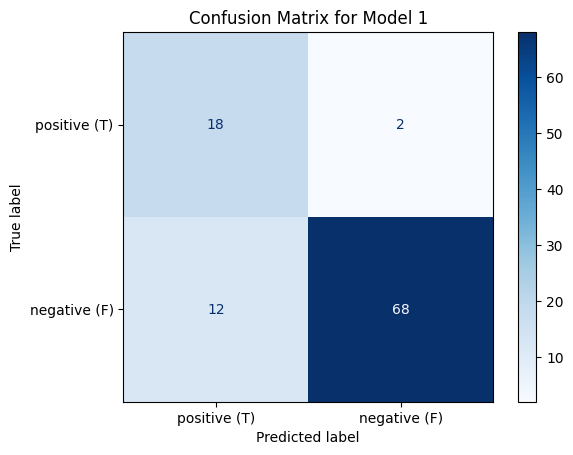

In [21]:
labels = ["positive (T)", "negative (F)"]
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_1,display_labels=labels)
disp.plot(cmap='Blues')
disp.ax_.set_title("Confusion Matrix for Model 1")
plt.show()

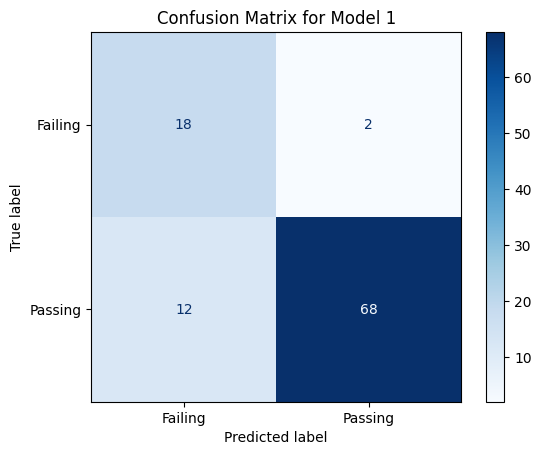

In [22]:
labels = ["Failing", "Passing"]
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_1,display_labels=labels)
disp.plot(cmap='Blues')
disp.ax_.set_title("Confusion Matrix for Model 1")
plt.show()

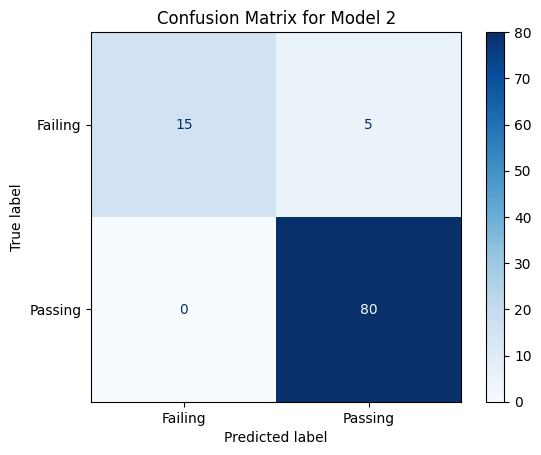

In [23]:
labels = ["Failing", "Passing"]
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_2,display_labels=labels)
disp.plot(cmap='Blues')
disp.ax_.set_title("Confusion Matrix for Model 2")
plt.show()

In [24]:
### A2-P2 b) Calculate the simple (overall) accuracy, average class accuracy (ACA) and the average class accuracy with harmonic mean for each model.

def compute_accuracy(confusion_matrix):
    TP = confusion_matrix[0][0]
    FN = confusion_matrix[0][1]
    FP = confusion_matrix[1][0]
    TN = confusion_matrix[1][1]

    simple_accuracy = (TP + TN) / (FN + FP + TN + TP)

    true_recall = TP / (TP + FN)
    true_precision = TP / (TP + FP)
    true_F1 = 2*true_recall*true_precision/(true_recall+true_precision)
    # print("true_F1", true_F1)
    false_recall = TN / (TN + FP)
    false_precision = TN / (TN + FN)
    false_F1 = 2*false_recall*false_precision/(false_recall+false_precision)
    # print("false_F1", false_F1)
    average_class_accuracy_AM = (1./2.)* (true_recall + false_recall)
    average_class_accuracy_HM = 2./(1./true_recall + 1./false_recall)

    print("true_recall", true_recall, "false_recal", false_recall)

    return simple_accuracy, average_class_accuracy_AM, average_class_accuracy_HM

In [25]:
simple_accuracy_1, average_class_accuracy_1a, average_class_accuracy_1b = compute_accuracy(confusion_matrix_1)
print("Model 1")
print("Simple Accuracy is " , simple_accuracy_1)
print("Average Class Accuracy (arithmetic mean) is " , average_class_accuracy_1a)
print("Average Class Accuracy (harmonic mean) is " , average_class_accuracy_1b)

true_recall 0.9 false_recal 0.85
Model 1
Simple Accuracy is  0.86
Average Class Accuracy (arithmetic mean) is  0.875
Average Class Accuracy (harmonic mean) is  0.8742857142857143


In [26]:
simple_accuracy_2, average_class_accuracy_2a, average_class_accuracy_2b = compute_accuracy(confusion_matrix_2)
print("Model 2")
print("Simple Accuracy is " , simple_accuracy_2)
print("Average Class Accuracy (arithmetic mean) is " , average_class_accuracy_2a)
print("Average Class Accuracy (harmonic mean) is " , average_class_accuracy_2b)

true_recall 0.75 false_recal 1.0
Model 2
Simple Accuracy is  0.95
Average Class Accuracy (arithmetic mean) is  0.875
Average Class Accuracy (harmonic mean) is  0.8571428571428572


In [27]:
### A2-P2 c) Based on a) and b), discuss which model appears to perform best at this task?
# Based on the average class accuracy measures, Model 2 appears to perform best! but at this threshold, Model 2 has 0 FP and 5 FN.
# We need to take a closer look at the performance for varying threhsold to decide which one is better.

In [28]:
### A2-P2 d) Compute precision and recall for each model. Based on this,
# discuss which model is better to use to make sure that
# we miss the least number of students to be given a warning.

def compute_precision_recall(confusion_matrix):
    TP = confusion_matrix[0][0]
    FN = confusion_matrix[0][1]
    FP = confusion_matrix[1][0]
    TN = confusion_matrix[1][1]

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    return precision, recall


precision_m1, recall_m1 = compute_precision_recall(confusion_matrix_1)
print("Model 1")
print("Precision", precision_m1)
print("Recall", recall_m1)

precision_m2, recall_m2 = compute_precision_recall(confusion_matrix_2)
print("Model 2")
print("Precision", precision_m2)
print("Recall", recall_m2)

Model 1
Precision 0.6
Recall 0.9
Model 2
Precision 1.0
Recall 0.75


In [29]:
# Regarding precision
# Out of all the predictions of students failing (P), model 1 is correct 60% in that prediction, and model 2 is 100%.
# Precsion of model 1 at the chosen threshold is not so good.

# Regarding recall
# Out of all the students that are failing (P), recall of Model 1 is 90%, but Model 2 is 75% for the given threshold.


# This means that Model 1 have identified the failing ones better than Model 2.
# Recall is good. But, you can also see that FP for Model 1 is very high!
# So, it is sending warning to so many students that are not failing (precision is bad).

In [30]:
### A2-P2 e) Generate precision and recall for a range of threshold on the prediction score and plot them on one figure.
# Which model is preferable based on this curve?

In [31]:
values = np.arange(0, 1.01, 0.01)
index = 0
p1 = [0] * len(values);
p2 = [0] * len(values);
r1 = [0] * len(values);
r2 = [0] * len(values);
for th in values:
    df_work = df_p2
    df_work['prediction_failing_1'] = df_work['model_1_score'].apply(lambda x: True if x < th else False)
    df_work['prediction_failing_2'] = df_work['model_2_score'].apply(lambda x: True if x < th else False)
    cm_1 = confusion_matrix(df_p2['prediction_failing_1'], df_p2['failing_course'])
    cm_2 = confusion_matrix(df_p2['prediction_failing_2'], df_p2['failing_course'])
    p1[index], r1[index] = compute_precision_recall(cm_1)
    p2[index], r2[index] = compute_precision_recall(cm_2)
    index += 1

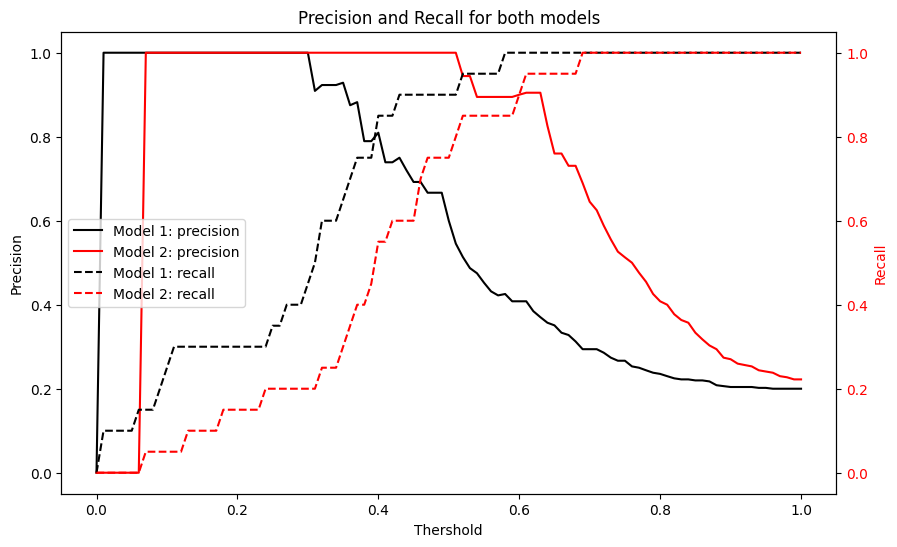

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot p1 and p2 on the left y-axis
ax1.plot(values, p1, 'k-', label='Model 1: precision')
ax1.plot(values, p2, 'r-', label='Model 2: precision')
ax1.set_xlabel('Thershold')
ax1.set_ylabel('Precision', color='k')
ax1.tick_params(axis='y', labelcolor='k')

# Create a second y-axis for r1 and r2
ax2 = ax1.twinx()
ax2.plot(values, r1, 'k--', label='Model 1: recall')
ax2.plot(values, r2, 'r--', label='Model 2: recall')
ax2.set_ylabel('Recall', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.title('Precision and Recall for both models')
plt.show()

In [33]:
### A2-P2 f) Explain how you may choose the threshold on the prediction score if you plan to minimize
# the warning given wrongly to passing students. Repeat for when you wanna make sure you
# won't miss a warning for failing student.
# Which model do you suggest to use based on these criteria?


# In order not to have FN, you wanna have recall of 100%. It seems the threshold should be increased.
# For large recall of Model 1, precision would be very low. Model 2 is better on this regard.
# A low precision means that we are warining many already passing students. So, maybe we can decrease the threshold,
# to make sure that no many students get wrong warning, while recall is still quite high.

In [34]:
### A2-P2 g) Given the generated figures so far, discuss which threshold value on the prediction score
# you would suggest to use for identifying those with failing potentials, and give the least number of
# wrong warnings to already passing students.

# around 0.6 threshold for Model 2 will give 90% recall and precision; this is one suggested threshold that identifies failing student by 90% (recall) and only around 10% will have a chance of getting wrong warning (precision).

# Otherwise to identify all failing students, models are also going to send lots of wrong warning. This is worse for Model 1.

In [35]:
### A2-P2 h) Construct (plot) the cumulative gain. Which model is better?

In [36]:
def plot_cumulative_gain(df, model_num, plot_name):
    size_of_decile = 10
    df_sorted = df.sort_values(by=["model_{}_score".format(model_num)], ascending=True)
    target_values = df_sorted["failing_course"].to_numpy().astype(int)
    total_positive = np.sum(target_values)
    gain_per_decile = []
    for decile in range(0, len(df),size_of_decile):
        # print(decile)
        true_positives = df_sorted["prediction_failing_{}".format(model_num)] & df_sorted["failing_course"]
        false_negatives = (df_sorted["prediction_failing_{}".format(model_num)]==False) & df_sorted["failing_course"]

        positives_per_decile = true_positives[decile:decile+size_of_decile]
        negatives_per_decile = false_negatives[decile:decile+size_of_decile]

        num_true_positives = positives_per_decile.sum()
        num_false_negatives = negatives_per_decile.sum()

        # print('TP', num_true_positives)
        # print('FN',num_false_negatives)

        gain_per_decile.append(num_true_positives + num_false_negatives)

    gain_per_decile = gain_per_decile / total_positive
    #print(df_sorted)
    #print('gain is', gain_per_decile)
    #print(true_positives)
    #print(total_positive)
    # Generate the plot
    x_labels = np.arange(1, 11, 1)
    cumulative = np.cumsum(gain_per_decile)
    print('cumulative gain is',cumulative)
        
    return x_labels, cumulative

cumulative gain is [0.45 0.8  0.9  0.95 1.   1.   1.   1.   1.   1.  ]
cumulative gain is [0.5 0.9 1.  1.  1.  1.  1.  1.  1.  1. ]


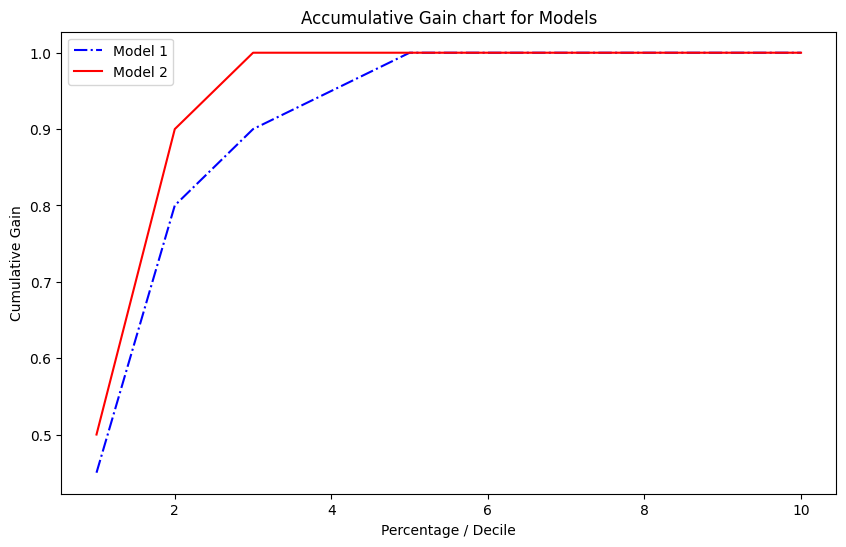

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

x1, y1 = plot_cumulative_gain(df_p2, "1", "Accumalative Gain chart for Model 1")
x2, y2 = plot_cumulative_gain(df_p2, "2", "Accumalative Gain chart for Model 2")


ax.plot(x1, y1, "-.", label="Model 1", color="blue")
ax.plot(x2, y2, label="Model 2", color="red")

ax.set_xlabel("Percentage / Decile")
ax.set_ylabel("Cumulative Gain")
ax.set_title("Accumulative Gain chart for Models")
ax.legend()

plt.show()

In [38]:
# Model 2 is better.

In [39]:
### A2-P2 i) Generate ROC curves for each model. 

In [40]:
def TPR_FPR(confusion_matrix):
    TP = confusion_matrix[0][0]
    FN = confusion_matrix[0][1]
    FP = confusion_matrix[1][0]
    TN = confusion_matrix[1][1]

    if (TP+FN != 0):
        true_positive_rate = TP / (TP + FN)
    else:
        true_positive_rate = 0  
    if (FP+TN != 0):
        false_positive_rate = FP / (FP + TN)
    else:
        false_positive_rate = 0  

    return true_positive_rate, false_positive_rate

In [41]:
index = 0
tpr1 = [0] * len(values);
tpr2 = [0] * len(values);
fpr1 = [0] * len(values);
fpr2 = [0] * len(values);
values = np.arange(0, 1.01, 0.01)
for th in values:
    df_work = df_p2
    df_work['prediction_failing_1'] = df_work['model_1_score'].apply(lambda x: True if x < th else False)
    df_work['prediction_failing_2'] = df_work['model_2_score'].apply(lambda x: True if x < th else False)
    CM_1 = confusion_matrix(df_p2['prediction_failing_1'], df_p2['failing_course'])
    CM_2 = confusion_matrix(df_p2['prediction_failing_2'], df_p2['failing_course'])
    tpr1[index], fpr1[index] = TPR_FPR(CM_1)
    tpr2[index], fpr2[index] = TPR_FPR(CM_2)
    index += 1

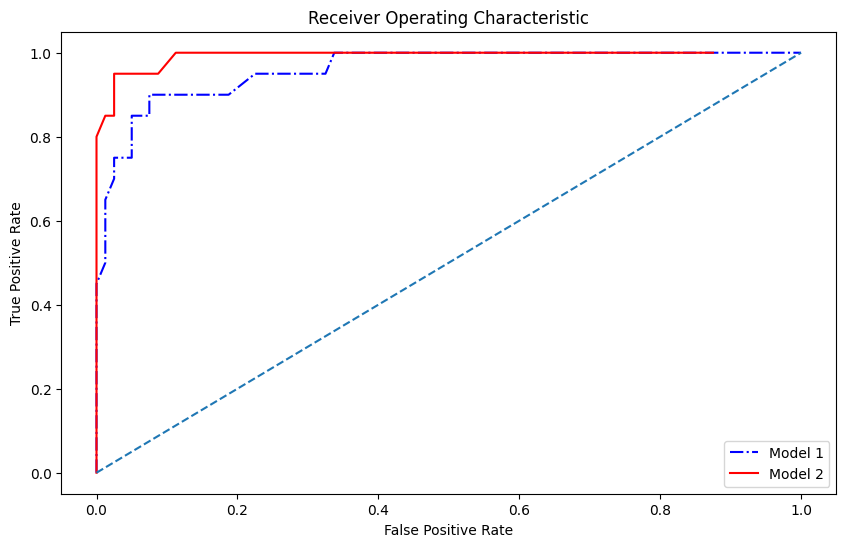

In [42]:
plt.subplots(1, figsize=(10,6))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr1, tpr1, "-.", color='b', label='Model 1') 
plt.plot(fpr2, tpr2, color='r', label='Model 2') 
plt.plot([0, 1], ls="--")
#plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend()
plt.show()

In [43]:
### A2-P2 j) The instructor plans to warn 90% of the failing students. Based on the cumulative gain plot,
# would you recommend Model 1 or Model 2 would perform best for the instructor to use.
# Explain why and refer to some statistics from the cumulative gain.

In [44]:
# Model 2 is better. By the second decile, we can idenfity 90% of the failing students for model 2.
# For model 1, the same percentage can be coverred in the first 30% bottom predicted scores.